# Time Series & Forecasting

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
# data = yf.download("BTC-USD", period="1mo", interval="1h")

btc = yf.Ticker("BTC-USD")
historical_1h = btc.history(period="6mo", interval="1h")

historical_1h.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-03-05 01:00:00+00:00,72815.109375,73261.585938,72462.257812,72492.882812,162013184,0.0,0.0
2026-03-05 02:00:00+00:00,72530.898438,72858.359375,72368.554688,72449.101562,150396928,0.0,0.0
2026-03-05 03:00:00+00:00,72510.953125,72735.304688,72373.562500,72513.132812,0,0.0,0.0
2026-03-05 04:00:00+00:00,72502.062500,73056.257812,72478.257812,72823.250000,0,0.0,0.0
2026-03-05 05:00:00+00:00,72847.929688,72887.843750,72514.367188,72514.367188,449462272,0.0,0.0


In [25]:
historical_1h.T

Datetime,2025-09-05 05:00:00+00:00,2025-09-05 06:00:00+00:00,2025-09-05 07:00:00+00:00,2025-09-05 08:00:00+00:00,2025-09-05 09:00:00+00:00,2025-09-05 10:00:00+00:00,2025-09-05 11:00:00+00:00,2025-09-05 12:00:00+00:00,2025-09-05 13:00:00+00:00,2025-09-05 14:00:00+00:00,...,2026-03-04 20:00:00+00:00,2026-03-04 21:00:00+00:00,2026-03-04 22:00:00+00:00,2026-03-04 23:00:00+00:00,2026-03-05 00:00:00+00:00,2026-03-05 01:00:00+00:00,2026-03-05 02:00:00+00:00,2026-03-05 03:00:00+00:00,2026-03-05 04:00:00+00:00,2026-03-05 05:00:00+00:00
Open,111454.898438,111589.187500,1.118953e+05,1.129672e+05,1.126306e+05,112294.421875,112261.734375,1.123422e+05,1.132250e+05,1.130640e+05,...,7.366957e+04,7.311063e+04,7.333452e+04,7.271069e+04,72729.273438,7.281511e+04,7.253090e+04,72510.953125,72502.062500,7.284793e+04
High,111698.046875,111859.859375,1.129786e+05,1.129672e+05,1.126306e+05,112498.109375,112381.304688,1.132838e+05,1.132661e+05,1.130640e+05,...,7.367408e+04,7.333089e+04,7.352450e+04,7.282932e+04,72990.601562,7.326159e+04,7.285836e+04,72735.304688,73056.257812,7.288784e+04
Low,111426.578125,111543.453125,1.118953e+05,1.126234e+05,1.121576e+05,112196.921875,112149.320312,1.123099e+05,1.128291e+05,1.105661e+05,...,7.315683e+04,7.291593e+04,7.266598e+04,7.233699e+04,72574.960938,7.246226e+04,7.236855e+04,72373.562500,72478.257812,7.251437e+04
Close,111594.609375,111859.859375,1.129666e+05,1.126328e+05,1.122896e+05,112251.585938,112341.570312,1.131495e+05,1.130322e+05,1.106079e+05,...,7.315683e+04,7.331846e+04,7.275545e+04,7.267012e+04,72822.906250,7.249288e+04,7.244910e+04,72513.132812,72823.250000,7.251437e+04
Volume,0.000000,0.000000,3.723489e+09,5.381284e+08,1.059189e+09,0.000000,0.000000,3.668734e+09,2.884039e+09,2.444501e+09,...,1.311703e+08,1.153753e+09,1.963950e+08,1.046553e+09,0.000000,1.620132e+08,1.503969e+08,0.000000,0.000000,4.494623e+08
Dividends,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
Stock Splits,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00


In [75]:
df = historical_1h

In [33]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Hour,Date_Only,Day_Name
Datetime,,,,,,,,,,
2025-09-05 05:00:00+00:00,111454.898438,111698.046875,111426.578125,111594.609375,0,0.0,0.0,9,2025-09-05,Friday
2025-09-05 06:00:00+00:00,111589.187500,111859.859375,111543.453125,111859.859375,0,0.0,0.0,9,2025-09-05,Friday
2025-09-05 07:00:00+00:00,111895.289062,112978.601562,111895.289062,112966.625000,3723489280,0.0,0.0,9,2025-09-05,Friday
2025-09-05 08:00:00+00:00,112967.164062,112967.164062,112623.406250,112632.773438,538128384,0.0,0.0,9,2025-09-05,Friday
2025-09-05 09:00:00+00:00,112630.625000,112630.625000,112157.648438,112289.562500,1059188736,0.0,0.0,9,2025-09-05,Friday
...,...,...,...,...,...,...,...,...,...,...
2026-03-05 01:00:00+00:00,72815.109375,73261.585938,72462.257812,72492.882812,162013184,0.0,0.0,3,2026-03-05,Thursday
2026-03-05 02:00:00+00:00,72530.898438,72858.359375,72368.554688,72449.101562,150396928,0.0,0.0,3,2026-03-05,Thursday
2026-03-05 03:00:00+00:00,72510.953125,72735.304688,72373.562500,72513.132812,0,0.0,0.0,3,2026-03-05,Thursday


In [34]:
df.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Hour            0
Date_Only       0
Day_Name        0
dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4314 entries, 2025-09-05 05:00:00+00:00 to 2026-03-05 05:00:00+00:00
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4314 non-null   float64
 1   High          4314 non-null   float64
 2   Low           4314 non-null   float64
 3   Close         4314 non-null   float64
 4   Volume        4314 non-null   int64  
 5   Dividends     4314 non-null   float64
 6   Stock Splits  4314 non-null   float64
 7   Hour          4314 non-null   int32  
 8   Date_Only     4314 non-null   object 
 9   Day_Name      4314 non-null   object 
dtypes: float64(6), int32(1), int64(1), object(2)
memory usage: 353.9+ KB


In [36]:
df['Hour'] = df.index.hour
df['Date_Only'] = df.index.date
df['Day_Name'] = df.index.day_name()
df['month'] = df.index.month

In [38]:
df.sort_index()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Hour,Date_Only,Day_Name,month
Datetime,,,,,,,,,,,
2025-09-05 05:00:00+00:00,111454.898438,111698.046875,111426.578125,111594.609375,0,0.0,0.0,5,2025-09-05,Friday,9
2025-09-05 06:00:00+00:00,111589.187500,111859.859375,111543.453125,111859.859375,0,0.0,0.0,6,2025-09-05,Friday,9
2025-09-05 07:00:00+00:00,111895.289062,112978.601562,111895.289062,112966.625000,3723489280,0.0,0.0,7,2025-09-05,Friday,9
2025-09-05 08:00:00+00:00,112967.164062,112967.164062,112623.406250,112632.773438,538128384,0.0,0.0,8,2025-09-05,Friday,9
2025-09-05 09:00:00+00:00,112630.625000,112630.625000,112157.648438,112289.562500,1059188736,0.0,0.0,9,2025-09-05,Friday,9
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-05 01:00:00+00:00,72815.109375,73261.585938,72462.257812,72492.882812,162013184,0.0,0.0,1,2026-03-05,Thursday,3
2026-03-05 02:00:00+00:00,72530.898438,72858.359375,72368.554688,72449.101562,150396928,0.0,0.0,2,2026-03-05,Thursday,3
2026-03-05 03:00:00+00:00,72510.953125,72735.304688,72373.562500,72513.132812,0,0.0,0.0,3,2026-03-05,Thursday,3


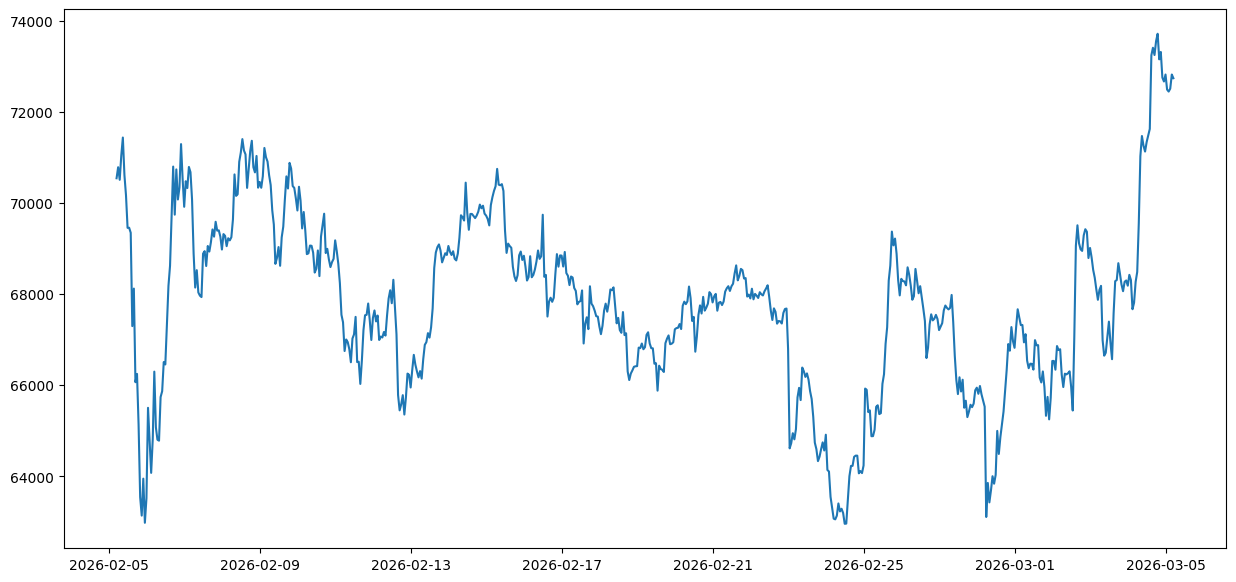

In [18]:
plt.figure(figsize=(15,7))
plt.plot(df['Close'])

In [53]:
df[['Close','month']]

,Close,month
Datetime,,
2025-09-05 05:00:00+00:00,111594.609375,9
2025-09-05 06:00:00+00:00,111859.859375,9
2025-09-05 07:00:00+00:00,112966.625000,9
2025-09-05 08:00:00+00:00,112632.773438,9
2025-09-05 09:00:00+00:00,112289.562500,9
...,...,...
2026-03-05 01:00:00+00:00,72492.882812,3
2026-03-05 02:00:00+00:00,72449.101562,3
2026-03-05 03:00:00+00:00,72513.132812,3


In [76]:
df_month = df.groupby(['month'])["Close"].mean()

In [77]:
df_month

month
1      90553.846050
2      69026.006516
3      68487.275544
9     113450.069770
10    114288.300211
11     96708.429877
12     89009.012191
Name: Close, dtype: float64

In [69]:
custom_order = [9, 10, 11, 12, 1, 2, 3]

In [80]:
df_month = df_month.reset_index()

In [81]:
df_month

,month,Close
0,1,90553.846050
1,2,69026.006516
2,3,68487.275544
3,9,113450.069770
4,10,114288.300211
5,11,96708.429877
6,12,89009.012191


In [106]:
df_month_fix = pd.concat((df_month.iloc[3:],df_month[0:3]))

In [107]:
df_month_fix

,month,Close
3,9,113450.069770
4,10,114288.300211
5,11,96708.429877
6,12,89009.012191
0,1,90553.846050
1,2,69026.006516
2,3,68487.275544


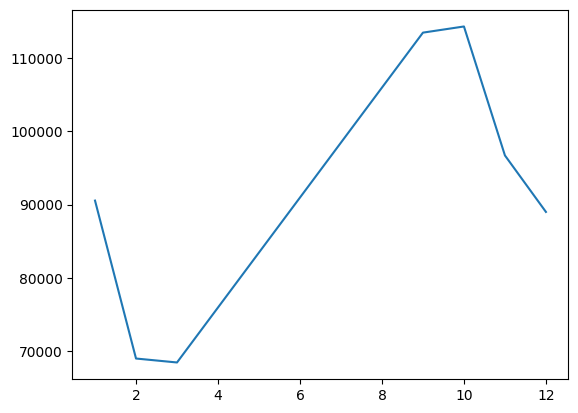

In [95]:
plt.plot(df.groupby(['month'])["Close"].mean())

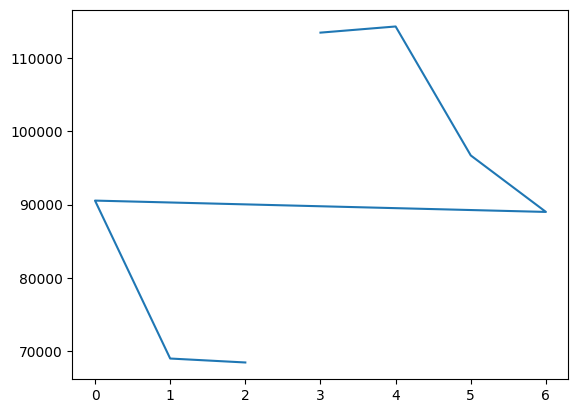

In [94]:
plt.plot(df.groupby(['month'])["Close"].mean())

In [103]:
df_month_fix['month']

3     9
4    10
5    11
6    12
0     1
1     2
2     3
Name: month, dtype: category
Categories (7, int64): [9 < 10 < 11 < 12 < 1 < 2 < 3]

In [104]:
df_month_fix

,month,Close
3,9,113450.069770
4,10,114288.300211
5,11,96708.429877
6,12,89009.012191
0,1,90553.846050
1,2,69026.006516
2,3,68487.275544


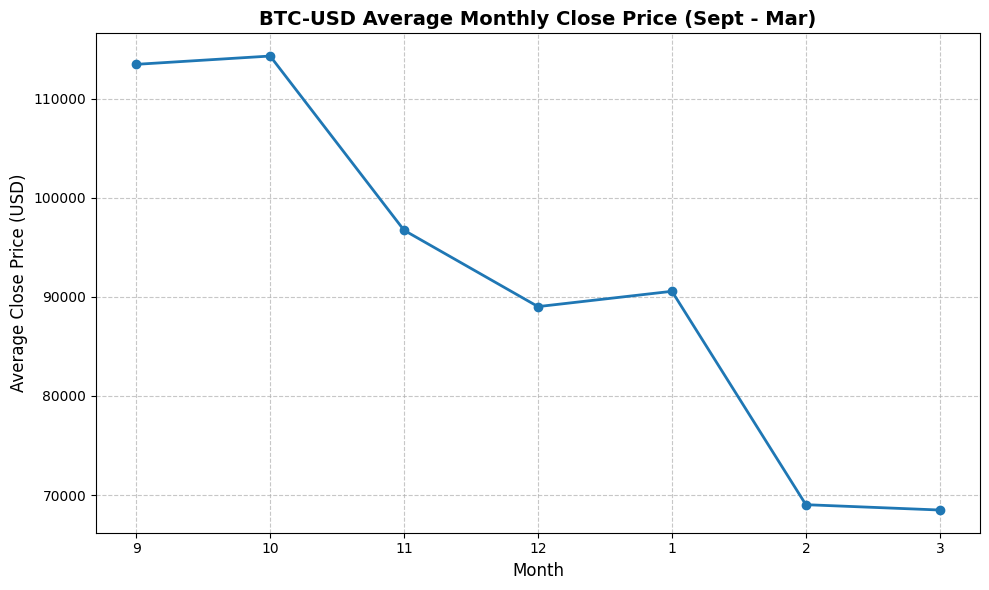

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Apply the chronological fix (if you haven't already applied it to df_month_fix)
custom_order = [9, 10, 11, 12, 1, 2, 3]
# df_month_fix['month'] = pd.Categorical(df_month_fix['month'], categories=custom_order, ordered=True)
# df_month_fix = df_month_fix.sort_values('month')

# 2. Set up the plot (Avoiding plt.figure as per best practices)
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot the data. Converting 'month' to a string forces the custom order on the X-axis
ax.plot(df_month_fix['month'].astype(str), df_month_fix['Close'], marker='o', linestyle='-', color='#1f77b4', linewidth=2)

# 4. Add formatting and labels
ax.set_title('BTC-USD Average Monthly Close Price (Sept - Mar)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Close Price (USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)

# 5. Show the plot
plt.tight_layout()
plt.show()

Fetching BTC-USD data from 2025-03-05 to 2026-03-05...
✓ Data fetched successfully! Total records: 365
  Date range: 2025-03-05 to 2026-03-05

✓ Line plot saved as 'btc_line_plot.png'
✓ OHLC line plot saved as 'btc_ohlc_line_plot.png'
✓ Moving Average line plot saved as 'btc_moving_average_plot.png'


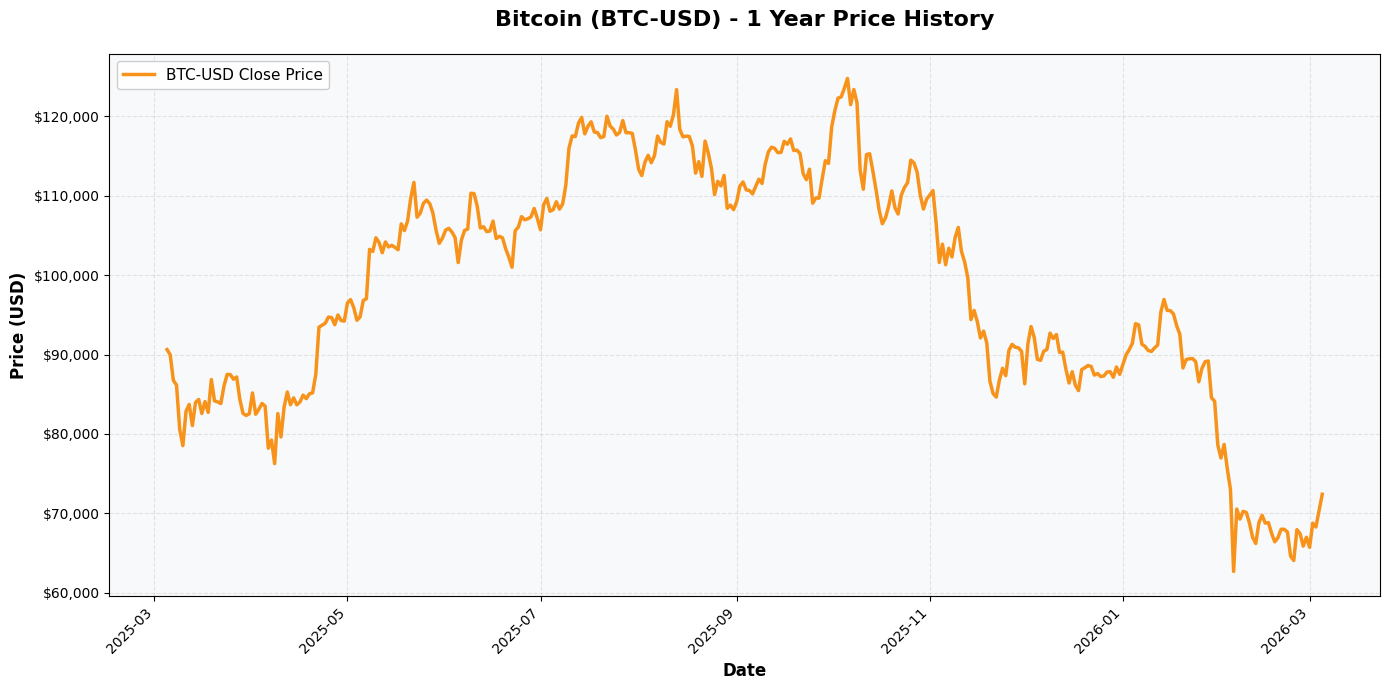

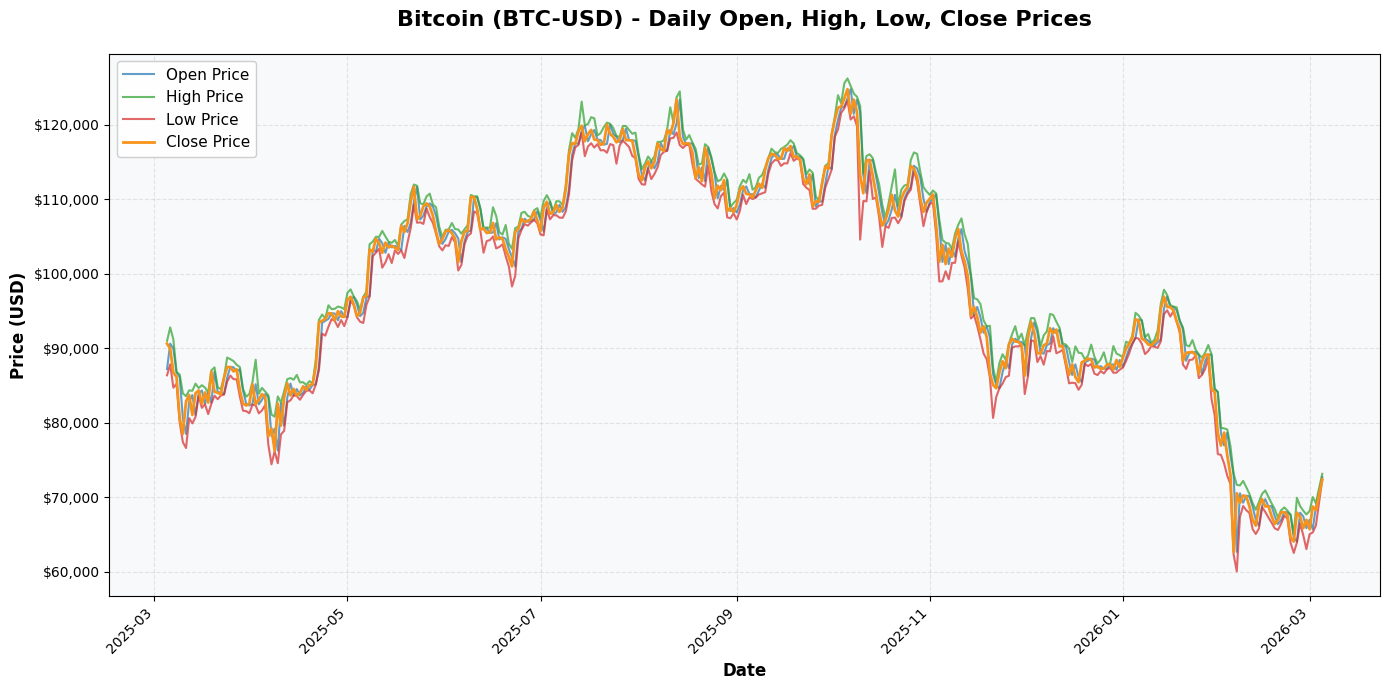

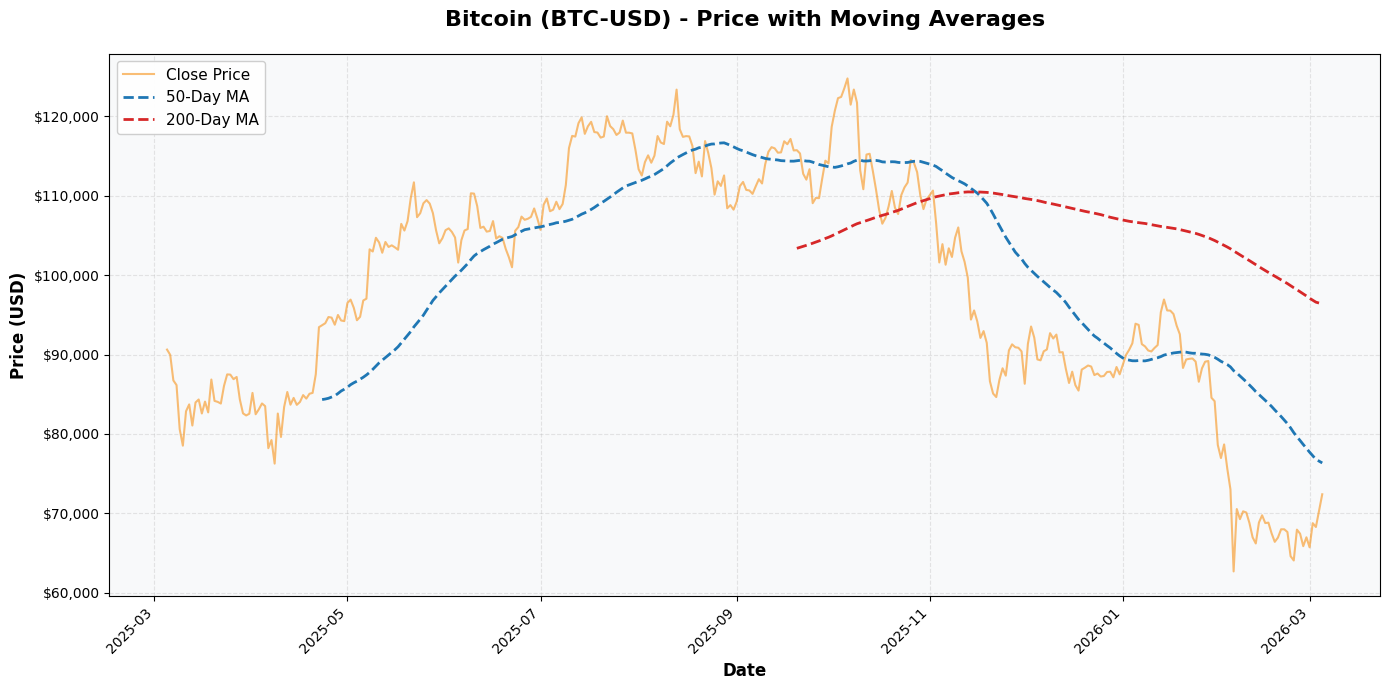

In [113]:
"""
BTC-USD Analysis Script
Fetches 1 year of Bitcoin historical data and creates visualizations

Requirements:
    pip install yfinance pandas matplotlib

Usage:
    python btc_analysis.py
"""

import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def fetch_and_analyze_btc():
    """Fetch BTC-USD data for past 1 year and create visualizations"""
    
    # Define date range: past 1 year
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365)
    
    print(f"Fetching BTC-USD data from {start_date.date()} to {end_date.date()}...")
    
    # Download historical data
    btc_data = yf.download('BTC-USD', start=start_date, end=end_date, progress=False)
    
    print(f"✓ Data fetched successfully! Total records: {len(btc_data)}")
    print(f"  Date range: {btc_data.index[0].date()} to {btc_data.index[-1].date()}")
    
    # ============================================================
    # PLOT 1: Line Plot - Closing Price
    # ============================================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(btc_data.index, btc_data['Close'], linewidth=2.5, color='#F7931A', 
            label='BTC-USD Close Price', zorder=2)
    
    # Customize the plot
    ax.set_title('Bitcoin (BTC-USD) - 1 Year Price History', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
    
    # Format y-axis to show currency
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Add background color
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')
    
    # Rotate x-axis labels for better readability
    fig.autofmt_xdate(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('btc_line_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("\n✓ Line plot saved as 'btc_line_plot.png'")
    
    # ============================================================
    # PLOT 2: Line Plot - Multiple Prices (Open, High, Low, Close)
    # ============================================================
    fig2, ax2 = plt.subplots(figsize=(14, 7))
    
    ax2.plot(btc_data.index, btc_data['Open'], linewidth=1.5, alpha=0.7, 
             label='Open Price', color='#1f77b4')
    ax2.plot(btc_data.index, btc_data['High'], linewidth=1.5, alpha=0.7, 
             label='High Price', color='#2ca02c')
    ax2.plot(btc_data.index, btc_data['Low'], linewidth=1.5, alpha=0.7, 
             label='Low Price', color='#d62728')
    ax2.plot(btc_data.index, btc_data['Close'], linewidth=2, 
             label='Close Price', color='#F7931A', zorder=3)
    
    ax2.set_title('Bitcoin (BTC-USD) - Daily Open, High, Low, Close Prices', 
                  fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax2.set_facecolor('#f8f9fa')
    fig2.patch.set_facecolor('white')
    
    fig2.autofmt_xdate(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('btc_ohlc_line_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ OHLC line plot saved as 'btc_ohlc_line_plot.png'")
    
    # ============================================================
    # PLOT 3: Line Plot - Moving Averages
    # ============================================================
    btc_data['MA_50'] = btc_data['Close'].rolling(window=50).mean()
    btc_data['MA_200'] = btc_data['Close'].rolling(window=200).mean()
    
    fig3, ax3 = plt.subplots(figsize=(14, 7))
    
    ax3.plot(btc_data.index, btc_data['Close'], linewidth=1.5, alpha=0.6, 
             label='Close Price', color='#F7931A')
    ax3.plot(btc_data.index, btc_data['MA_50'], linewidth=2, 
             label='50-Day MA', color='#1f77b4', linestyle='--')
    ax3.plot(btc_data.index, btc_data['MA_200'], linewidth=2, 
             label='200-Day MA', color='#d62728', linestyle='--')
    
    ax3.set_title('Bitcoin (BTC-USD) - Price with Moving Averages', 
                  fontsize=16, fontweight='bold', pad=20)
    ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax3.set_facecolor('#f8f9fa')
    fig3.patch.set_facecolor('white')
    
    fig3.autofmt_xdate(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('btc_moving_average_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Moving Average line plot saved as 'btc_moving_average_plot.png'")
    
    plt.show()

if __name__ == "__main__":
    fetch_and_analyze_btc()

In [120]:
btc_data = yf.download('BTC-USD', period='1y',progress=False)

In [121]:
btc_data

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-03-05,90623.562500,90998.242188,86379.773438,87222.953125,50498988027
2025-03-06,89961.726562,92804.937500,87852.140625,90622.359375,47749810486
2025-03-07,86742.671875,91191.046875,84717.679688,89963.281250,65945677657
2025-03-08,86154.593750,86847.265625,85247.484375,86742.656250,18206118081
2025-03-09,80601.039062,86471.132812,80052.484375,86154.304688,30899345977
...,...,...,...,...,...
2026-02-28,66995.859375,67714.523438,63062.218750,65878.929688,42041497112
2026-03-01,65738.101562,68162.820312,65076.730469,67005.882812,40733141929


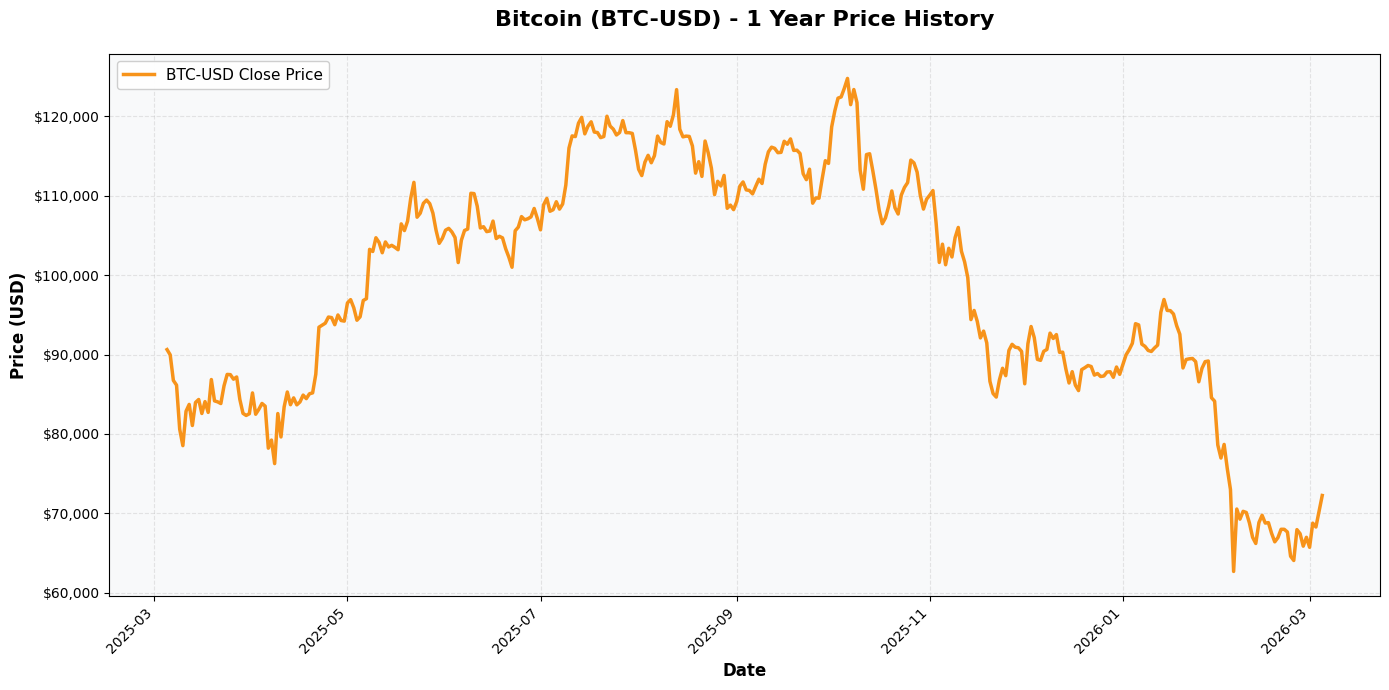

In [124]:
fig, ax = plt.subplots(figsize=(14, 7))
    
ax.plot(btc_data.index, btc_data['Close'], linewidth=2.5, color='#F7931A', 
        label='BTC-USD Close Price', zorder=2)

# Customize the plot
ax.set_title('Bitcoin (BTC-USD) - 1 Year Price History', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# Format y-axis to show currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add background color
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Rotate x-axis labels for better readability
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

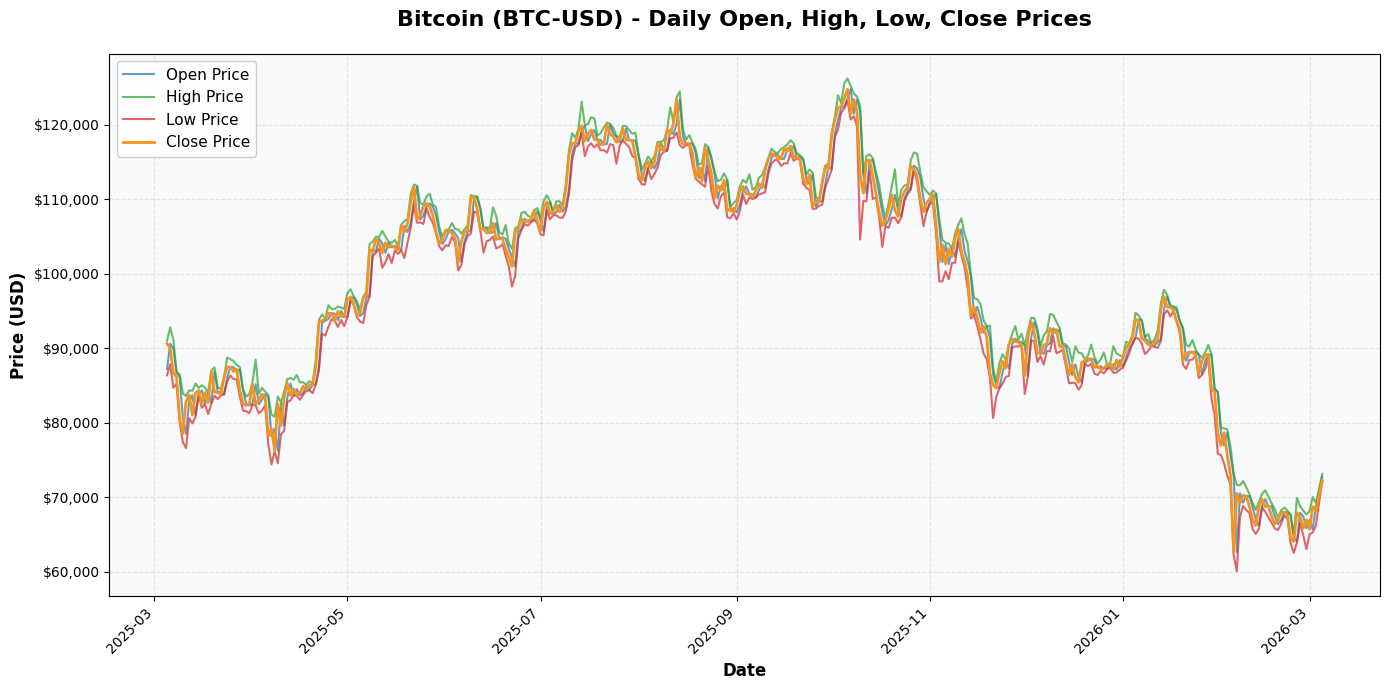

In [125]:
fig2, ax2 = plt.subplots(figsize=(14, 7))

ax2.plot(btc_data.index, btc_data['Open'], linewidth=1.5, alpha=0.7, 
         label='Open Price', color='#1f77b4')
ax2.plot(btc_data.index, btc_data['High'], linewidth=1.5, alpha=0.7, 
         label='High Price', color='#2ca02c')
ax2.plot(btc_data.index, btc_data['Low'], linewidth=1.5, alpha=0.7, 
         label='Low Price', color='#d62728')
ax2.plot(btc_data.index, btc_data['Close'], linewidth=2, 
         label='Close Price', color='#F7931A', zorder=3)

ax2.set_title('Bitcoin (BTC-USD) - Daily Open, High, Low, Close Prices', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax2.set_facecolor('#f8f9fa')
fig2.patch.set_facecolor('white')

fig2.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()

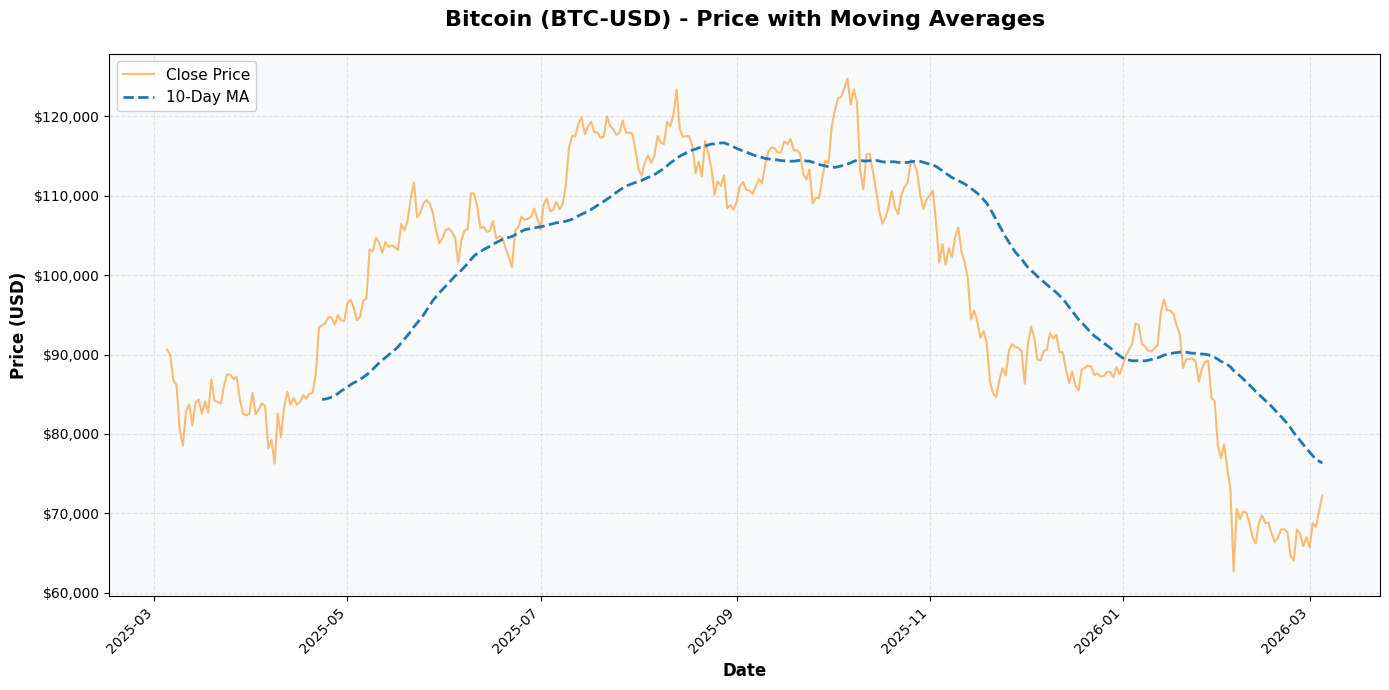

In [130]:
btc_data['MA_10'] = btc_data['Close'].rolling(window=10).mean()

    
fig3, ax3 = plt.subplots(figsize=(14, 7))

ax3.plot(btc_data.index, btc_data['Close'], linewidth=1.5, alpha=0.6, 
         label='Close Price', color='#F7931A')
ax3.plot(btc_data.index, btc_data['MA_50'], linewidth=2, 
         label='10-Day MA', color='#1f77b4', linestyle='--')

ax3.set_title('Bitcoin (BTC-USD) - Price with Moving Averages', 
              fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
ax3.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax3.set_facecolor('#f8f9fa')
fig3.patch.set_facecolor('white')

fig3.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout() 
plt.show()

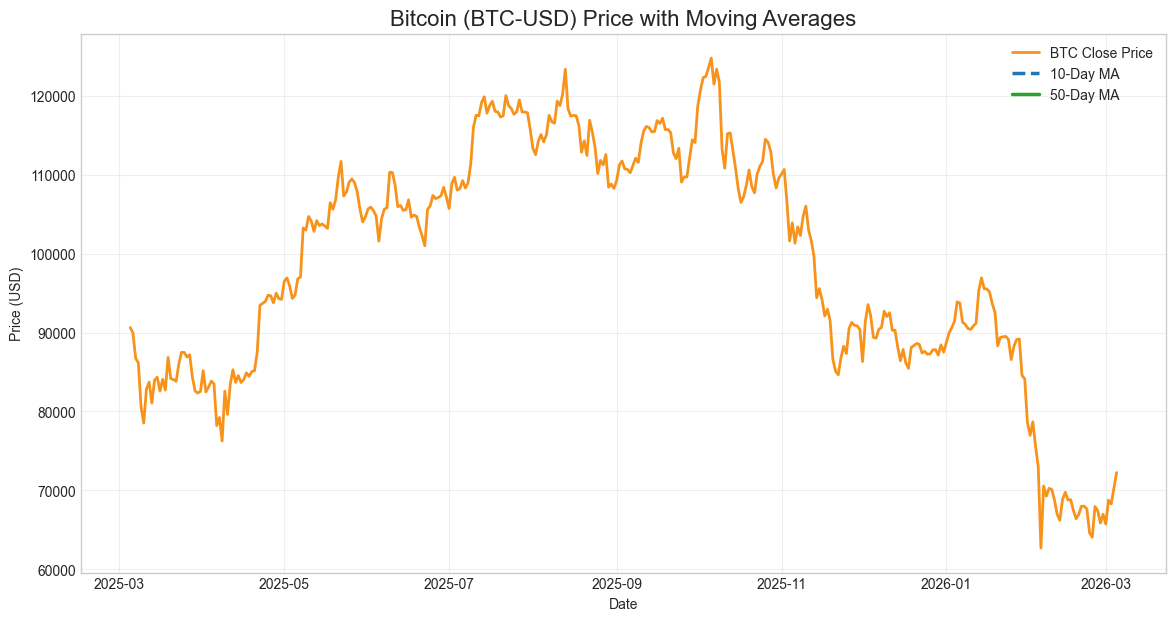

In [137]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Moving averages
btc_data['MA_10'] = btc_data['Close'].rolling(window=10).mean()
btc_data['MA_50'] = btc_data['Close'].rolling(window=50).mean()

fig, ax = plt.subplots(figsize=(14,7))

# BTC price
ax.plot(
    btc_data.index,
    btc_data['Close'],
    label='BTC Close Price',
    color='#F7931A',
    linewidth=2
)

# 10 day MA
ax.plot(
    btc_data.index,
    btc_data['MA_10'],
    label='10-Day MA',
    color='#1f77b4',
    linestyle='--',
    linewidth=2.5
)

# 50 day MA
ax.plot(
    btc_data.index,
    btc_data['MA_50'],
    label='50-Day MA',
    color='#2ca02c',
    linewidth=2.5
)

ax.set_title("Bitcoin (BTC-USD) Price with Moving Averages", fontsize=16)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [138]:
!pip install --quiet  pmdarima statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm

In [140]:
btc = yf.download("BTC-USD", start="2017-01-01")

data = btc[['Close']].copy()
data.rename(columns={"Close":"Price"}, inplace=True)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Price
Ticker,BTC-USD
Date,
2017-01-01,998.325012
2017-01-02,1021.750000
2017-01-03,1043.839966
2017-01-04,1154.729980
2017-01-05,1013.380005


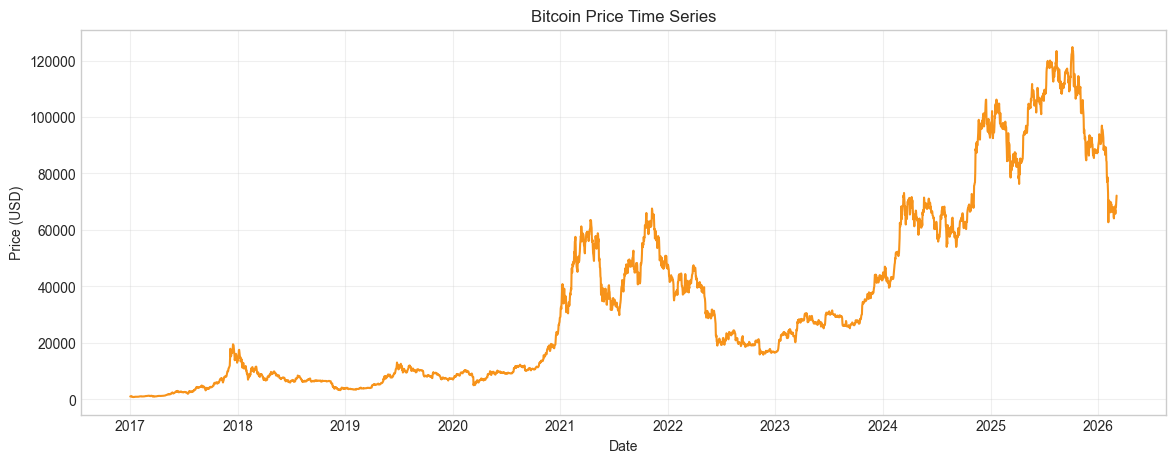

In [141]:
plt.figure(figsize=(14,5))

plt.plot(data.index, data.Price, color="#F7931A")

plt.title("Bitcoin Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)

plt.show()

In [142]:
data["Price"].isna().sum()

Ticker
BTC-USD    0
dtype: int64

In [143]:
data["Price"] = data["Price"].interpolate()

In [144]:
z = np.abs((data.Price - data.Price.mean()) / data.Price.std())

data["Price_clean"] = np.where(
    z > 3,
    data.Price.median(),
    data.Price
)

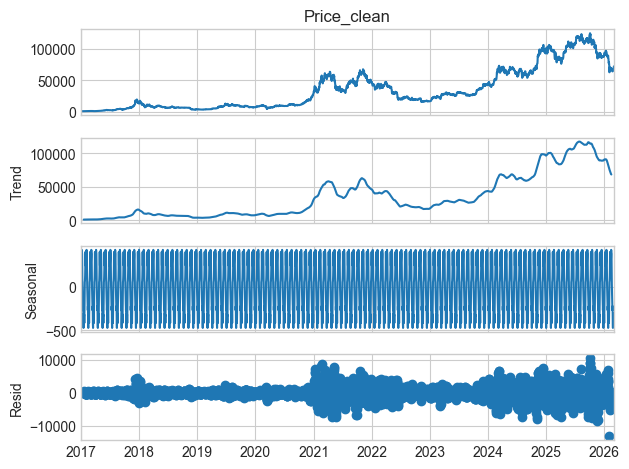

In [145]:
decomp = seasonal_decompose(
    data.Price_clean,
    model="additive",
    period=30
)

decomp.plot()

plt.show()

In [146]:
result = adfuller(data.Price_clean.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.1653417090377984
p-value: 0.6883243939588022


In [147]:
train = data.Price_clean[:-30]
test = data.Price_clean[-30:]

In [148]:
model = pm.auto_arima(
    train,
    seasonal=True,
    m=7,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=8.14 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=56724.479, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=56723.809, Time=0.32 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=56723.844, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=56723.654, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=56726.457, Time=0.20 sec
 ARIMA(0,1,0)(0,0,1)[7] intercept   : AIC=56726.458, Time=0.27 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=56728.448, Time=1.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=56721.878, Time=0.12 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=56723.811, Time=0.37 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=56722.813, Time=2.37 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=56723.863, Time=0.21 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=56723.871, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=56721.909, Time=0.15 sec
 ARIMA(2,1,1)(0,0,0)[7] i

In [157]:
forecast, conf_int = model.predict(
    n_periods=30,
    return_conf_int=True
)

forecast = pd.Series(forecast, index=test.index)

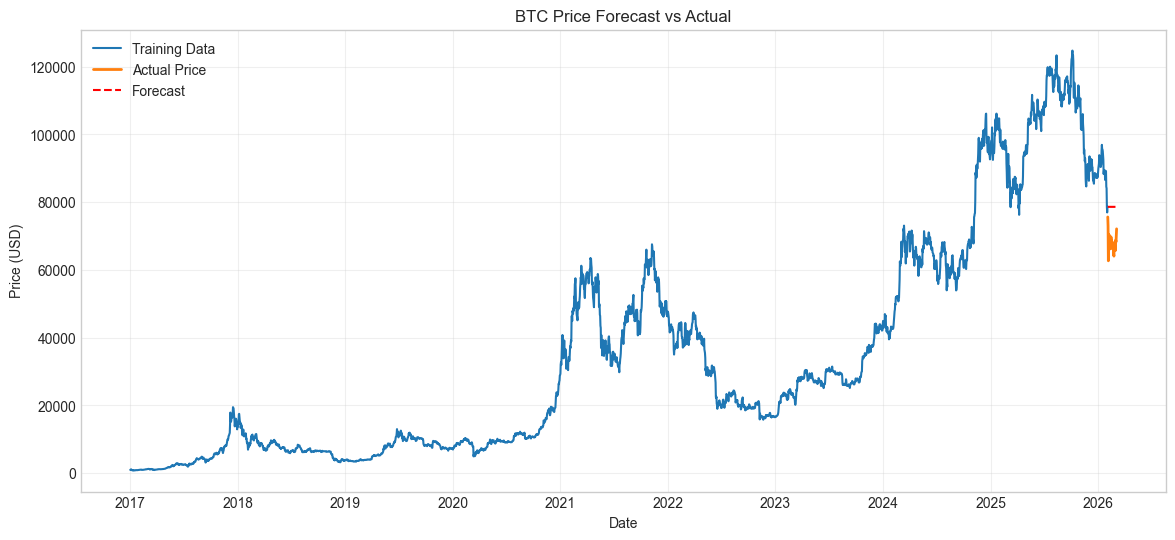

In [158]:
plt.figure(figsize=(14,6))

plt.plot(train, label="Training Data")

plt.plot(test, label="Actual Price", linewidth=2)

plt.plot(
    forecast,
    label="Forecast",
    linestyle="--",
    color="red"
)

plt.title("BTC Price Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [159]:
print("NaN in test:", test.isna().sum())
print("NaN in forecast:", forecast.isna().sum())

NaN in test: 0
NaN in forecast: 1


In [160]:
df_eval = pd.concat([test, forecast], axis=1)
df_eval.columns = ["Actual", "Forecast"]

df_eval = df_eval.dropna()

In [161]:
df_eval

,Actual,Forecast
Date,,
2026-02-03,75633.546875,78625.574271
2026-02-04,73019.703125,78627.903560
2026-02-05,62702.097656,78627.817700
2026-02-06,70555.390625,78627.820865
2026-02-07,69281.968750,78627.820748
2026-02-08,70264.726562,78627.820753
2026-02-09,70120.781250,78627.820752
2026-02-10,68793.960938,78627.820752
2026-02-11,66991.968750,78627.820752


In [162]:
mae = mean_absolute_error(df_eval["Actual"], df_eval["Forecast"])
rmse = np.sqrt(mean_squared_error(df_eval["Actual"], df_eval["Forecast"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 10552.422630920733
RMSE: 10845.006952209955


## Technical Indicators

### Moving Averages (MA)
- **MA10:** Average price of the last 10 days.
- **MA30:** Average price of the last 30 days.

### Volatility
Measures price variability.
- **Formula:** Standard deviation of the last 10 prices.
- **Interpretation:** High volatility → unstable market.

### Momentum
Measures price strength and direction.

**Example:**

| Price Today | Price 10 Days Ago | Momentum |
| :--- | :--- | :--- |
| 70000 | 65000 | +5000 |

*Note:* Positive momentum means uptrend strength.

### Bollinger Bands
Identifies potential overbought or oversold conditions based on price action relative to dynamic bands.

**If price hits:**

| Position | Meaning |
| :--- | :--- |
| Upper band | Overbought |
| Lower band | Oversold |

### Moving Average Convergence Divergence (MACD)
Measures trend momentum to identify the strength and direction of a price trend.

- **Mechanism:** Compares a Short-term EMA vs. a Long-term EMA.
- **Interpretation:** If MACD > 0 → bullish momentum.

[*********************100%***********************]  1 of 1 completed

                  Price       Volume
Date                                
2020-01-01  7200.174316  18565664997
2020-01-02  6985.470215  20802083465
2020-01-03  7344.884277  28111481032
2020-01-04  7410.656738  18444271275
2020-01-05  7411.317383  19725074095


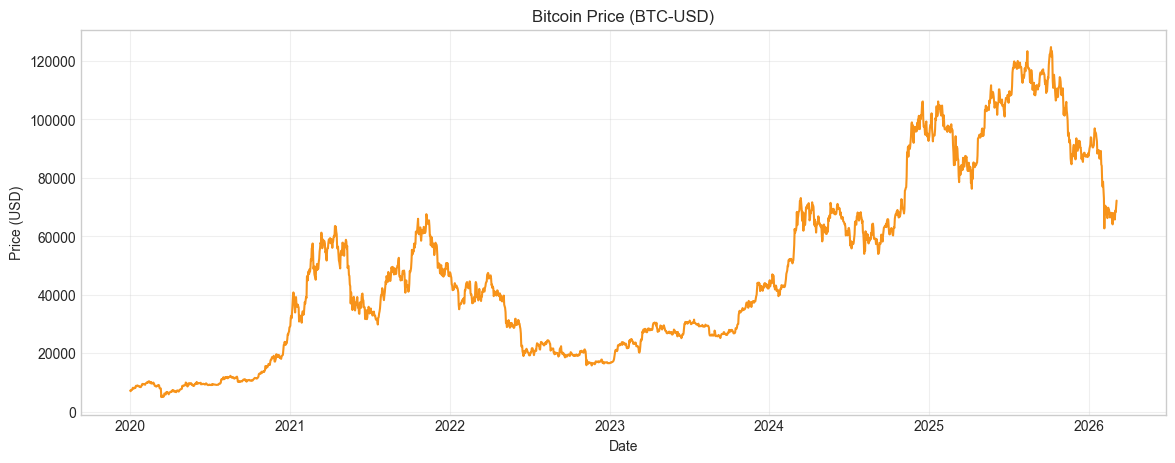

MAE: 7257.885270130952
RMSE: 9101.554249949453


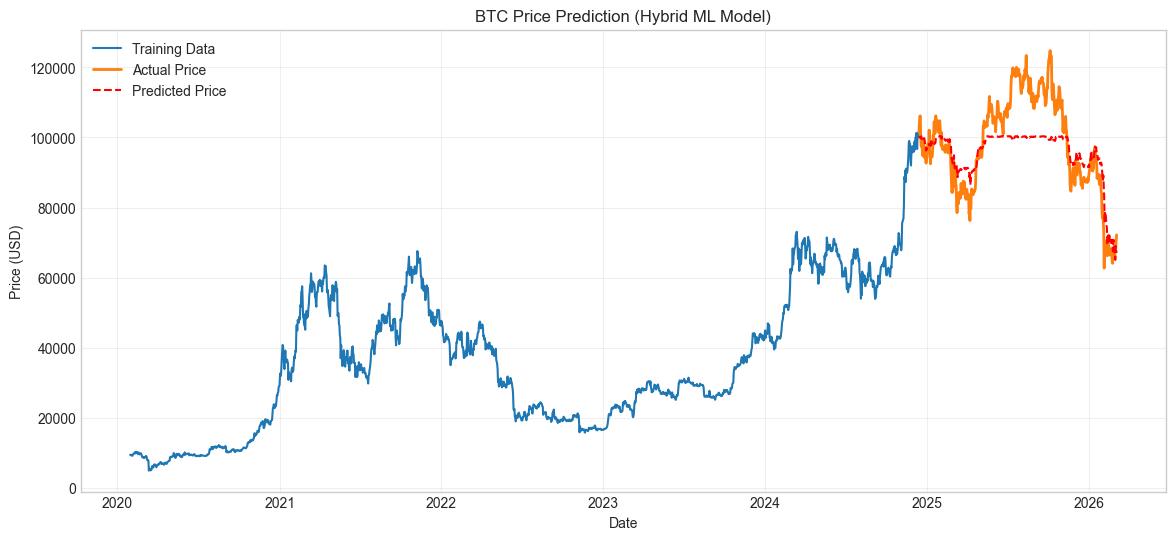

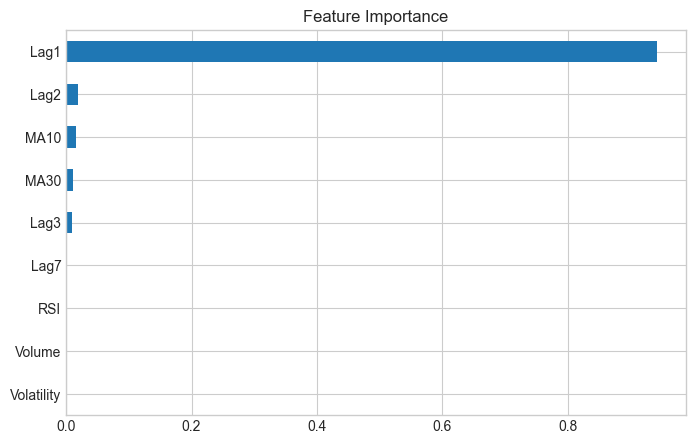

In [164]:
# =====================================
# 1. Install Required Libraries
# =====================================

# !pip install --quiet yfinance scikit-learn matplotlib pandas numpy

# =====================================
# 2. Import Libraries
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================
# 3. Download BTC Data
# =====================================

btc = yf.download("BTC-USD", start="2020-01-01")

data = pd.DataFrame()
data["Price"] = btc["Close"].squeeze()
data["Volume"] = btc["Volume"].squeeze()

print(data.head())

# =====================================
# 4. Plot BTC Price
# =====================================

plt.figure(figsize=(14,5))

plt.plot(data.index, data["Price"], color="#F7931A")

plt.title("Bitcoin Price (BTC-USD)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)

plt.show()

# =====================================
# 5. Create Technical Indicators
# =====================================

# Moving averages
data["MA10"] = data["Price"].rolling(10).mean()
data["MA30"] = data["Price"].rolling(30).mean()

# RSI (simple implementation)
delta = data["Price"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data["RSI"] = 100 - (100 / (1 + rs))

# Volatility
data["Volatility"] = data["Price"].rolling(10).std()

# =====================================
# 6. Create Lag Features
# =====================================

data["Lag1"] = data["Price"].shift(1)
data["Lag2"] = data["Price"].shift(2)
data["Lag3"] = data["Price"].shift(3)
data["Lag7"] = data["Price"].shift(7)

# =====================================
# 7. Remove Missing Values
# =====================================

data = data.dropna()

# =====================================
# 8. Define Features and Target
# =====================================

features = [
    "MA10",
    "MA30",
    "RSI",
    "Volatility",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag7",
    "Volume"
]

X = data[features]
y = data["Price"]

# =====================================
# 9. Train/Test Split (Time Series)
# =====================================

split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# =====================================
# 10. Train Random Forest Model
# =====================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================
# 11. Predictions
# =====================================

predictions = model.predict(X_test)

predictions = pd.Series(predictions, index=y_test.index)

# =====================================
# 12. Model Evaluation
# =====================================

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

# =====================================
# 13. Plot Predictions
# =====================================

plt.figure(figsize=(14,6))

plt.plot(y_train, label="Training Data")

plt.plot(y_test, label="Actual Price", linewidth=2)

plt.plot(
    predictions,
    label="Predicted Price",
    linestyle="--",
    color="red"
)

plt.title("BTC Price Prediction (Hybrid ML Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# =====================================
# 14. Feature Importance
# =====================================

importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed


MAE: 1983.5480934910715
RMSE: 2575.6015195538594


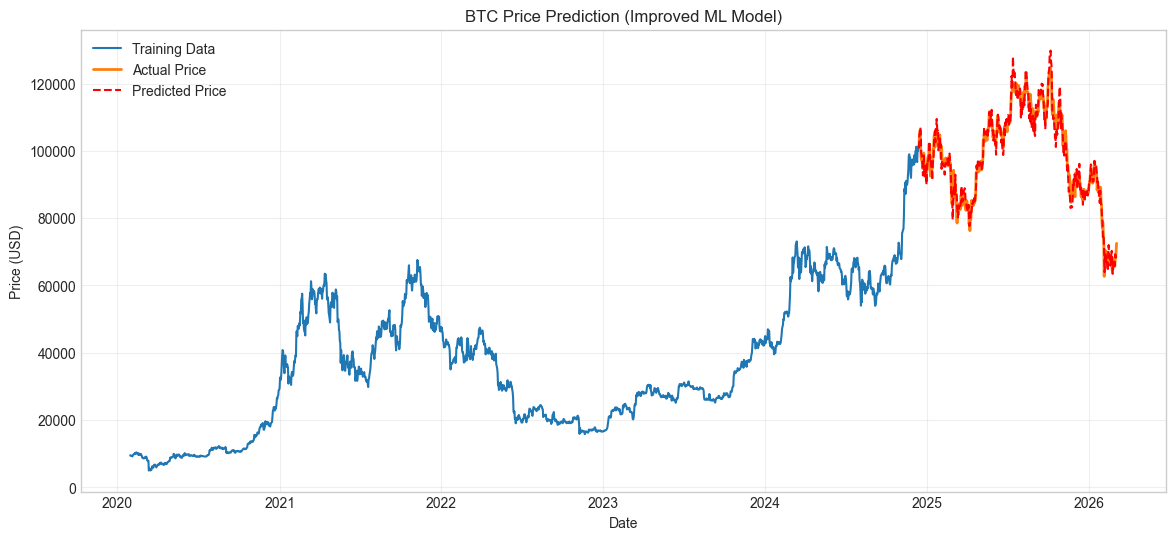

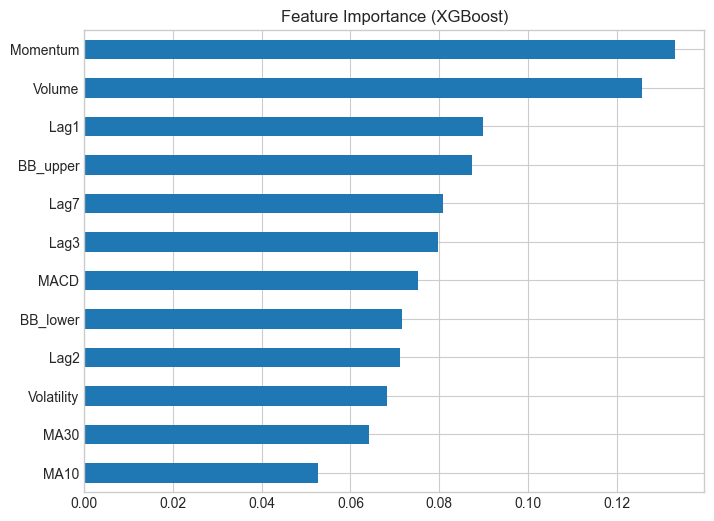

Direction Accuracy: 0.6053811659192825


In [165]:
# ============================================
# 1. Install Required Libraries
# ============================================

!pip install --quiet xgboost

# ============================================
# 2. Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================
# 3. Download BTC Data
# ============================================

btc = yf.download("BTC-USD", start="2020-01-01")

data = pd.DataFrame()
data["Price"] = btc["Close"].squeeze()
data["Volume"] = btc["Volume"].squeeze()

# ============================================
# 4. Create Target Variable (Returns)
# ============================================

data["Return"] = data["Price"].pct_change()

# Direction classification target
data["Direction"] = (data["Return"] > 0).astype(int)

# ============================================
# 5. Technical Indicators
# ============================================

# Moving averages
data["MA10"] = data["Price"].rolling(10).mean()
data["MA30"] = data["Price"].rolling(30).mean()

# Volatility
data["Volatility"] = data["Price"].rolling(10).std()

# Momentum
data["Momentum"] = data["Price"] - data["Price"].shift(10)

# Bollinger Bands
rolling_mean = data["Price"].rolling(20).mean()
rolling_std = data["Price"].rolling(20).std()

data["BB_upper"] = rolling_mean + 2 * rolling_std
data["BB_lower"] = rolling_mean - 2 * rolling_std

# MACD
ema12 = data["Price"].ewm(span=12, adjust=False).mean()
ema26 = data["Price"].ewm(span=26, adjust=False).mean()

data["MACD"] = ema12 - ema26

# ============================================
# 6. Lag Features
# ============================================

data["Lag1"] = data["Return"].shift(1)
data["Lag2"] = data["Return"].shift(2)
data["Lag3"] = data["Return"].shift(3)
data["Lag7"] = data["Return"].shift(7)

# ============================================
# 7. Drop Missing Values
# ============================================

data = data.dropna()

# ============================================
# 8. Feature Selection
# ============================================

features = [
    "MA10",
    "MA30",
    "Volatility",
    "Momentum",
    "BB_upper",
    "BB_lower",
    "MACD",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag7",
    "Volume"
]

X = data[features]
y = data["Return"]

# ============================================
# 9. Train/Test Split (Time-Series Safe)
# ============================================

split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# ============================================
# 10. Train XGBoost Model
# ============================================

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

# ============================================
# 11. Predictions
# ============================================

pred_returns = model.predict(X_test)

pred_returns = pd.Series(pred_returns, index=y_test.index)

# Convert returns to predicted price

pred_price = data["Price"].shift(1).loc[pred_returns.index] * (1 + pred_returns)

# ============================================
# 12. Evaluation
# ============================================

actual_price = data["Price"].loc[pred_price.index]

mae = mean_absolute_error(actual_price, pred_price)
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))

print("MAE:", mae)
print("RMSE:", rmse)

# ============================================
# 13. Plot Predictions
# ============================================

plt.figure(figsize=(14,6))

plt.plot(data["Price"][:split], label="Training Data")

plt.plot(actual_price, label="Actual Price", linewidth=2)

plt.plot(pred_price, label="Predicted Price", linestyle="--", color="red")

plt.title("BTC Price Prediction (Improved ML Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ============================================
# 14. Feature Importance
# ============================================

importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance (XGBoost)")

plt.show()

# ============================================
# 15. Direction Accuracy
# ============================================

pred_direction = (pred_returns > 0).astype(int)

actual_direction = (y_test > 0).astype(int)

accuracy = (pred_direction == actual_direction).mean()

print("Direction Accuracy:", accuracy)

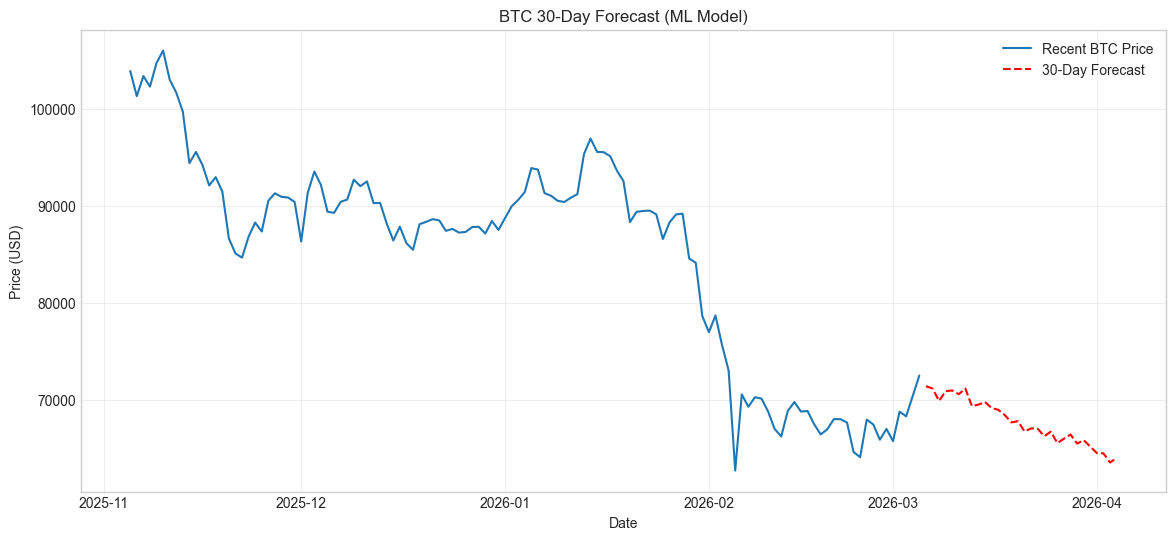

In [167]:
###### plt.figure(figsize=(14,6))

plt.plot(data["Price"].tail(120), label="Recent BTC Price")

plt.plot(future_prices, label="30-Day Forecast", linestyle="--", color="red")

plt.title("BTC 30-Day Forecast (ML Model)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [166]:
# ============================================
# 16. Forecast Next 30 Days
# ============================================

future_days = 30

last_data = data.copy()

future_prices = []

current_price = last_data["Price"].iloc[-1]

for i in range(future_days):

    # get last row features
    last_row = last_data.iloc[-1]

    features_input = last_row[features].values.reshape(1, -1)

    # predict return
    pred_return = model.predict(features_input)[0]

    # convert to price
    next_price = current_price * (1 + pred_return)

    future_prices.append(next_price)

    # create new row
    new_row = last_row.copy()

    new_row["Price"] = next_price
    new_row["Return"] = pred_return

    # update lag features
    new_row["Lag1"] = pred_return
    new_row["Lag2"] = last_row["Lag1"]
    new_row["Lag3"] = last_row["Lag2"]
    new_row["Lag7"] = last_row["Lag3"]

    # append row
    last_data = pd.concat([last_data, pd.DataFrame([new_row])])

    current_price = next_price

# create future index
future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

future_prices = pd.Series(future_prices, index=future_dates)

print(future_prices)

2026-03-06    71399.846852
2026-03-07    71171.810330
2026-03-08    69883.543758
2026-03-09    70887.167993
2026-03-10    70959.148576
2026-03-11    70574.700184
2026-03-12    71159.919584
2026-03-13    69340.290088
2026-03-14    69510.619422
2026-03-15    69764.329709
2026-03-16    69153.021247
2026-03-17    68969.277807
2026-03-18    68426.693861
2026-03-19    67668.675177
2026-03-20    67793.677298
2026-03-21    66732.215008
2026-03-22    67055.987575
2026-03-23    67015.763294
2026-03-24    66245.880842
2026-03-25    66715.088488
2026-03-26    65535.077322
2026-03-27    65994.898973
2026-03-28    66410.106452
2026-03-29    65484.481741
2026-03-30    65839.452477
2026-03-31    65174.999404
2026-04-01    64509.129028
2026-04-02    64475.381079
2026-04-03    63539.037816
2026-04-04    64005.578093
Freq: D, dtype: float64
